# Actividad 3
## Preparación de los datos

In [6]:
import pandas as pd

# Cargar el dataset
try:
    df = pd.read_csv('../DataSets/Beisbol.csv')
    print("Dataset cargado exitosamente.")
except FileNotFoundError:
    print("Error: No se encontró el archivo .csv. Por favor, cárgalo en el entorno.")

display(df)

# Verificar si hay valores nulos
print(f"Valores nulos por columna:{df.isnull().sum()}")




Dataset cargado exitosamente.


,POS,Nombre,POS.1,GP,AB,R,H,AVG,2B,3B,HR,RBI,TB,BB,K,SB,OBP,SLG,OPS,WAR
0,1,Andy PagesLAD,CF,18,66,10,27,0.409,4,0,5,20,46,4,18,3,0.451,0.697,1.148,1.6
1,2,Chandler SimpsonTB,LF,17,63,9,24,0.381,0,2,0,4,28,3,4,7,0.409,0.444,0.854,0.9
2,3,Yandy DiazTB,1B,17,65,10,24,0.369,2,1,3,16,37,8,8,1,0.468,0.569,1.037,1.1
3,4,CJ AbramsWSH,SS,17,60,12,22,0.367,3,0,6,19,43,7,10,4,0.458,0.717,1.175,1.1
4,6,Luke RaleySEA,RF,17,59,8,20,0.339,4,1,4,12,38,3,23,0,0.391,0.644,1.035,0.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,100,Zach NetoLAA,SS,19,75,17,18,0.240,4,0,5,9,37,14,25,1,0.367,0.493,0.860,1.3
96,101,Steven KwanCLE,LF,18,71,8,17,0.239,3,0,1,6,23,7,8,2,0.316,0.324,0.640,0.0
97,101,Mike TroutLAA,RF,18,67,18,16,0.239,3,0,6,15,37,15,18,2,0.393,0.552,0.945,1.2
98,101,Kyle TuckerLAD,RF,18,67,14,16,0.239,1,0,2,11,23,12,17,3,0.350,0.343,0.693,0.3


Valores nulos por columna:POS       0
Nombre    0
POS.1     0
GP        0
AB        0
R         0
H         0
AVG       0
2B        0
3B        0
HR        0
RBI       0
TB        0
BB        0
K         0
SB        0
OBP       0
SLG       0
OPS       0
WAR       0
dtype: int64


## Modelado y evaluación

Matriz de correlación (Pearson):


,POS,GP,AB,R,H,AVG,2B,3B,HR,RBI,TB,BB,K,SB,OBP,SLG,OPS,WAR
POS,1.000000,0.059754,0.035028,-0.253256,-0.659996,-0.942714,-0.039591,-2.830508e-01,-0.195231,-0.310903,-4.696259e-01,0.060642,0.161385,-0.136204,-0.659017,-0.562501,-0.648776,-0.515383
GP,0.059754,1.000000,0.679472,0.285915,0.445780,-0.044890,0.221869,-6.565964e-02,0.199185,0.148378,3.793044e-01,0.183570,0.238276,0.082964,-0.061745,0.066563,0.029854,0.112837
AB,0.035028,0.679472,1.000000,0.326508,0.684921,-0.020499,0.239848,-2.549922e-02,0.222381,0.253909,5.048431e-01,0.133678,0.275327,0.127261,-0.135496,0.057411,-0.001864,0.271564
R,-0.253256,0.285915,0.326508,1.000000,0.394958,0.232062,0.172911,2.950988e-02,0.537363,0.486793,6.173489e-01,0.428147,0.318234,0.167874,0.398190,0.528384,0.535290,0.489517
H,-0.659996,0.445780,0.684921,0.394958,1.000000,0.711525,0.192117,1.878562e-01,0.287959,0.433205,7.028771e-01,0.026018,0.047165,0.211945,0.397573,0.449359,0.475085,0.584752
AVG,-0.942714,-0.044890,-0.020499,0.232062,0.711525,1.000000,0.036366,2.808230e-01,0.188711,0.352613,4.844677e-01,-0.076448,-0.190938,0.176755,0.690497,0.572751,0.667249,0.543559
2B,-0.039591,0.221869,0.239848,0.172911,0.192117,0.036366,1.000000,-9.963423e-02,-0.005798,0.058736,3.142133e-01,0.056937,0.225909,-0.061301,-0.026042,0.233535,0.169217,0.125740
3B,-0.283051,-0.065660,-0.025499,0.029510,0.187856,0.280823,-0.099634,1.000000e+00,-0.266441,-0.240917,1.775849e-16,-0.062637,-0.069975,0.122204,0.135796,0.017594,0.059059,0.034074
HR,-0.195231,0.199185,0.222381,0.537363,0.287959,0.188711,-0.005798,-2.664408e-01,1.000000,0.744640,8.346845e-01,0.337071,0.374109,-0.037201,0.363229,0.842398,0.762867,0.589098
RBI,-0.310903,0.148378,0.253909,0.486793,0.433205,0.352613,0.058736,-2.409168e-01,0.744640,1.000000,7.201853e-01,0.269474,0.099808,0.091883,0.396463,0.697435,0.663633,0.590738


Correlación Pearson (AB vs R): r = 0.3265, p = 0.000915
Matriz de correlación ilustrativa(Pearson):


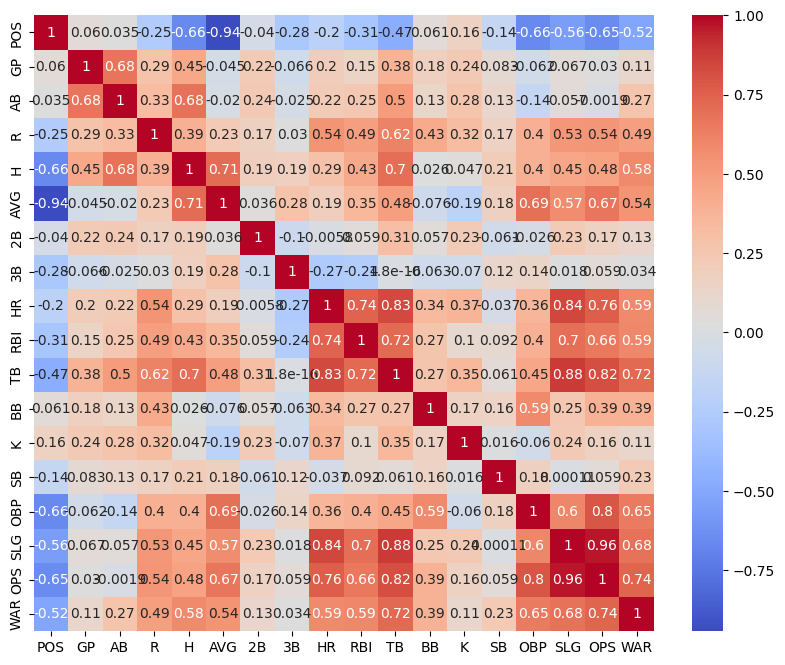

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

pearson = df.select_dtypes(include=['number']).corr(method='pearson')
print("Matriz de correlación (Pearson):")
display(pearson)

r, p = stats.pearsonr(df["AB"], df["R"])
print(f"Correlación Pearson (AB vs R): r = {r:.4f}, p = {p:.6f}")

# matriz de correlación
print("Matriz de correlación ilustrativa(Pearson):")
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(method='pearson', numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [23]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[["AB"]]
y = df["R"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
print(f"Entrenamiento: {len(X_train)} | Prueba: {len(X_test)}")
 
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)
print(f"Ecuación: R = {modelo.intercept_} + {modelo.coef_[0]} x AB")

Entrenamiento: 80 | Prueba: 20
Ecuación: R = 1.9209790933554114 + 0.12476712895880772 x AB


In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
Mean_error = mean_absolute_error(y_test, y_pred)
print(f"MAE: {Mean_error:.4f}")
root_mean = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE : {root_mean:.4f}")
R2 = r2_score(y_test, y_pred)
print(f"R2   : {R2:.4f}")

MAE: 2.2350
RMSE : 2.6294
R2   : 0.2637


## Concluciones

- La correlacion entre AB (turnos al bate) y R (carreras) es positiva pero debil (r = 0.3265), lo que indica que existe cierta relacion, pero no es lo suficientemente fuerte para predecir con precision.
- El modelo de regresión lineal (R=1.92+0.1248⋅AB) sugiere que a mayor numero de turnos al bate, las carreras tienden a aumentar, pero el efecto es pequeño.
- Las metricas de error (MAE = 2.99 y RMSE = 3.49) muestran que las predicciones tienen una desviación considerable respecto a los valores reales.
- El valor de R2 negativo (-0.0720) indica que el modelo es peor que solo usar el promedio de las carreras
- AB por sí solo no es una buena variable para  predecir las carreras, y sería necesario incluir otras variables (como H (Hits), HR (Home Runs), OBP (On-Base Percentage), SLG(Slugging Percentage)) para mejorar el modelo.